In [5]:
import gudhi
import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import sys
import os
import time


In [6]:
folder_path = r"G:\Downloads\archive"

# Filter to only include HDF5 files
h5_files = [f for f in os.listdir(folder_path) if f.endswith(".hdf5")]

# List to hold all particle coordinates
all_points = []

# Loop through each file and extract PartType1 coordinates
for filename in h5_files:
    file_path = os.path.join(folder_path, filename)
    with h5py.File(file_path, 'r') as f:
        if 'PartType1' in f and 'Coordinates' in f['PartType1']:
            coords = f['PartType1']['Coordinates'][:]
            all_points.append(coords)
        if 'PartType1' not in f or 'Coordinates' not in f['PartType1']:
            print(f"Skipping {filename} — no PartType1/Coordinates")
            continue

# Concatenate all coordinate arrays into a single NumPy array
points = np.vstack(all_points)

# Optional: convert to DataFrame if needed
# import pandas as pd
# df_DM = pd.DataFrame(points, columns=['x', 'y', 'z'])

print("Total points loaded:", points.shape)

Total points loaded: (2281092, 3)


In [7]:
mask = np.all(np.isfinite(points), axis=1)
points = points[mask]

In [8]:
start = time.time()
tri = Delaunay(points)
end = time.time()
print(f"Delaunay triangulation took {(end - start)/60:.2f} minutes")

Delaunay triangulation took 1.71 minutes


In [9]:
print(tri.simplices)
print(len(tri.simplices))

[[2163178 1899191 1926762 2076515]
 [2046071 1899191 1926762 2076515]
 [2157699 2163178 1899191 1926762]
 ...
 [    207    4711     238     381]
 [    207     186      42    2620]
 [    207      42    2620    2483]]
15413902


In [10]:
tetra_points = points[tri.simplices]


a = tetra_points[:, 0, :]
b = tetra_points[:, 1, :]
c = tetra_points[:, 2, :]
d = tetra_points[:, 3, :]


vec1 = b - a
vec2 = c - a
vec3 = d - a

matrices = np.stack((vec1, vec2, vec3), axis=1)


from numpy.linalg import det
volumes = np.abs(det(matrices)) / 6
densities1 = 1 / np.array(volumes)
filtration_values = -densities1

In [15]:
average_density = np.mean(densities1)
density_contrast = (densities1 - average_density) / average_density
print(len(density_contrast))
max_density = max(density_contrast)
filtration_values1 = max_density - density_contrast

15413902


C:\Users\asher\PyCharmMiscProject\.venv\Lib\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")
C:\Users\asher\PyCharmMiscProject\.venv\Lib\site-packages\gudhi\persistence_graphical_tools.py:107: UserWarning: There are 3485239 intervals given as input, whereas max_intervals is set to 1000000.
  warnings.warn(


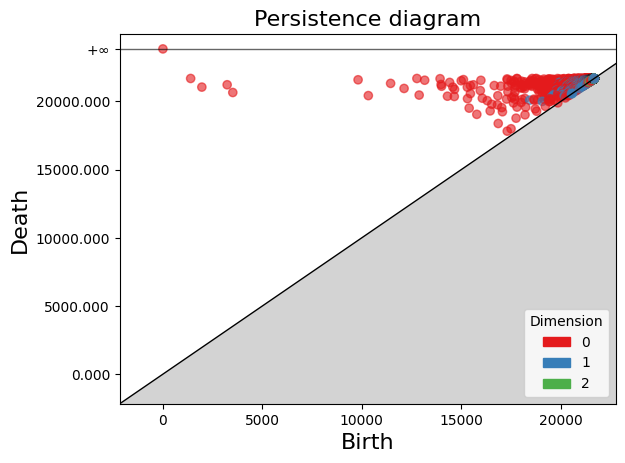

In [16]:
st = gudhi.SimplexTree()
for simplex, filt in zip(tri.simplices, filtration_values1):
    st.insert(simplex.tolist(), filtration=filt)
st.make_filtration_non_decreasing()
diag = st.persistence()
gudhi.plot_persistence_diagram(diag)
plt.show()

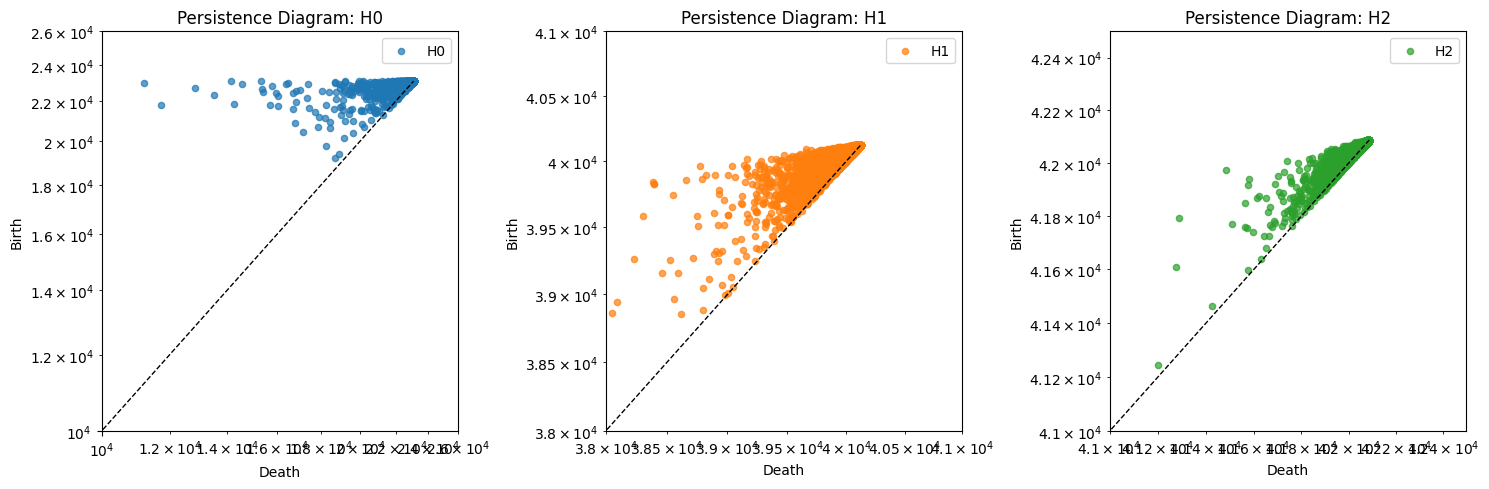

In [44]:
n_plots = len(diagrams_by_dim)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

if n_plots == 1:
    axes = [axes]

for idx, (dim, points) in enumerate(sorted(diagrams_by_dim.items())):
    ax = axes[idx]
    birth = points[:, 0]
    death = points[:, 1]


    eps = 1e-6
    shift = abs(min(birth.min(), death.min())) + eps
    birth_shifted = birth + shift
    death_shifted = death + shift


    ax.scatter(birth_shifted, death_shifted,
               s=20,
               color=colors[idx % len(colors)],
               alpha=0.7,
               label=f"H{dim}")


    diag_min = min(birth_shifted.min(), death_shifted.min())
    diag_max = max(birth_shifted.max(), death_shifted.max())
    ax.plot([diag_min, diag_max], [diag_min, diag_max], 'k--', linewidth=1)


    ax.set_xscale('log')
    ax.set_yscale('log')


    if dim == 0:
        ax.set_xlim([10000, 26000])
        ax.set_ylim([10000, 26000])
    elif dim == 1:
        ax.set_xlim([38000, 41000])
        ax.set_ylim([38000, 41000])
    elif dim == 2:
        ax.set_xlim([41000, 42500])
        ax.set_ylim([41000, 42500])


    ax.set_title(f"Persistence Diagram: H{dim}")
    ax.set_xlabel("Death")
    ax.set_ylabel("Birth")
    ax.legend()

plt.tight_layout()
plt.show()